<a href="https://colab.research.google.com/github/lipchenko/machine_learning_lipchenko/blob/main/my_classification_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ДОМАШНЕЕ ЗАДАНИЕ

### **Задача:** повторите туториал на датасете **Iris**

**Датасет Iris:**
- 150 примеров цветков ириса
- 3 вида (Setosa, Versicolor, Virginica)
- 4 признака (длина/ширина чашелистика и лепестка)

### **Требования:**
1. **часть 1-2: анализ данных**
   - загрузите датасет `sklearn.datasets.load_iris()`
   - создайте 2 графика распределения классов
   - визуализируйте данные в 2D (выберите 2 любых признака)

2. **часть 3-5: подготовка и обучение**
   - разделите данные 70/30 с `stratify`
   - масштабируйте признаки
   - обучите SVM с линейным ядром

3. **часть 6: эксперименты**
   - попробуйте 3 разных значения C: 0.1, 1, 10
   - сравните accuracy каждой модели
   - выберите лучшую

4. **часть 7-8: оценка**
   - постройте матрицу ошибок для лучшей модели
   - вычислите precision, recall, F1-score
   - найдите и проанализируйте 2 примера ошибок

5. **часть 9: анализ**
   - постройте кривую обучения
   - ответьте: модель переобучается или недообучается?
   - что можно улучшить?

### **Формат сдачи:**
- **Colab ноутбук** с выполненным кодом
- **краткий отчет** (3-5 предложений) с выводами:
  - какая точность достигнута?
  - на каких классах чаще ошибается модель?
  - какие параметры SVM сработали лучше всего?

### **Критерии оценки:**
1. корректная загрузка и анализ данных
2. правильное разделение и масштабирование
3. обучение SVM с разными параметрами (показать, что вы делали как минимум 2 прогона с разными гиперпараметрами, 1 прогон даёт 1 балл)
4. визуализация матрицы ошибок
5. вычисление метрик precision, recall, F1
6. построение кривой обучения
7. представлены ответы на все вопросы из списка требований

### **Дедлайн:** 14 февраля, 23:59 в свои учебные репозитории

In [25]:

!pip install numpy pandas matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [26]:
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"Размер данных: {X.shape}")
print(f"Количество классов: {len(np.unique(y))}")
print(f"Названия классов: {target_names}")
print(f"Признаки: {feature_names}")

Размер данных: (150, 4)
Количество классов: 3
Названия классов: ['setosa' 'versicolor' 'virginica']
Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [27]:
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

df['iris_type'] = df['target'].map({0: target_names[0],
                                     1: target_names[1],
                                     2: target_names[2]})
print("Первые 5 строк:")
print(df.head())


print("\nБазовая статистика:")
print(df.describe())

print("\nРаспределение классов:")
print(df['iris_type'].value_counts())

Первые 5 строк:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target iris_type  
0       0    setosa  
1       0    setosa  
2       0    setosa  
3       0    setosa  
4       0    setosa  

Базовая статистика:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000       

/tmp/ipython-input-2268306859.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='iris_type', data=df, palette='Set2')


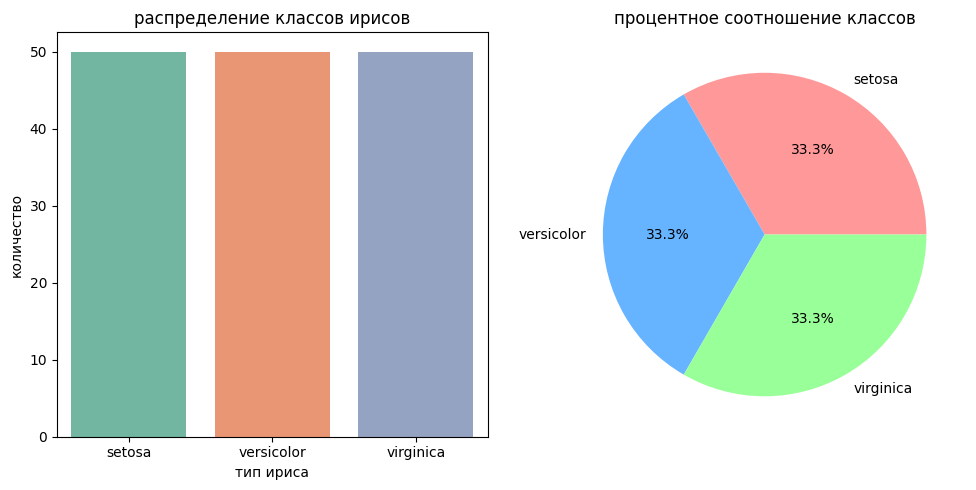

In [28]:
#2 графика
plt.figure(figsize=(10, 5))

# гистограмма по классам
plt.subplot(1, 2, 1)
sns.countplot(x='iris_type', data=df, palette='Set2')
plt.title('распределение классов ирисов')
plt.xlabel('тип ириса')
plt.ylabel('количество')

# круговая диаграмма
plt.subplot(1, 2, 2)
class_counts = df['target'].value_counts()
plt.pie(class_counts, labels=target_names, autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('процентное соотношение классов')

plt.tight_layout()
plt.show()

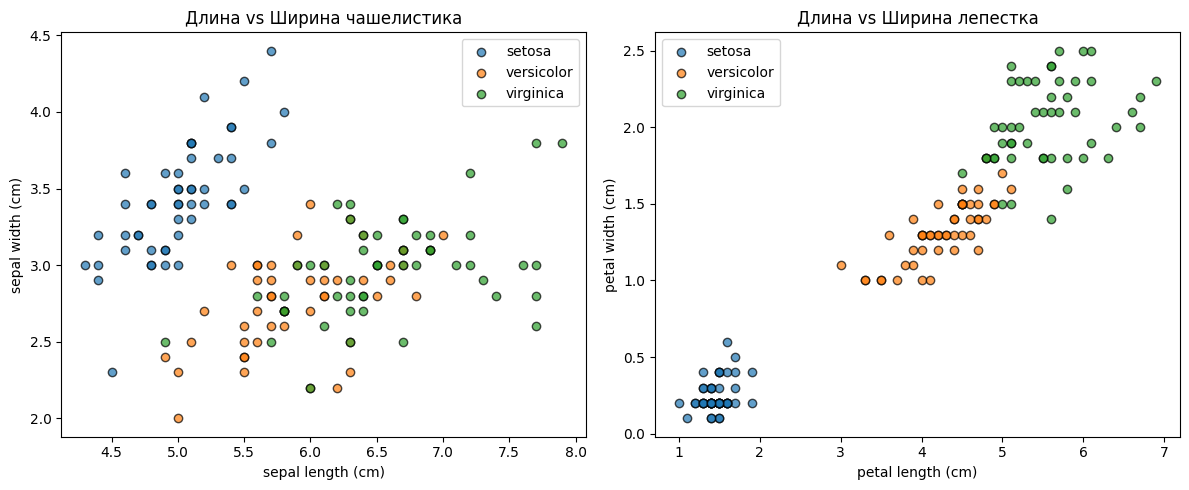

In [29]:
#два 2д графика
plt.figure(figsize=(12, 5))

#график по длине и ширине чашелистинка
plt.subplot(1, 2, 1)
for i, iris_class in enumerate(target_names):
    plt.scatter(df[df['iris_type'] == iris_class]['sepal length (cm)'],
                df[df['iris_type'] == iris_class]['sepal width (cm)'],
                label=iris_class, alpha=0.7, edgecolor='k')
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.legend()
plt.title('Длина vs Ширина чашелистика')

#здесь представлена длина и ширина лепестка
plt.subplot(1, 2, 2)
for i, iris_class in enumerate(target_names):
    plt.scatter(df[df['iris_type'] == iris_class]['petal length (cm)'],
                df[df['iris_type'] == iris_class]['petal width (cm)'],
                label=iris_class, alpha=0.7, edgecolor='k')
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.legend()
plt.title('Длина vs Ширина лепестка')

plt.tight_layout()
plt.show()

In [30]:
# разделяем данные (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"train size: {X_train.shape}")
print(f"test size: {X_test.shape}")
print(f"train class distribution: {np.bincount(y_train)}")
print(f"test class distribution: {np.bincount(y_test)}")


train size: (105, 4)
test size: (45, 4)
train class distribution: [35 35 35]
test class distribution: [15 15 15]


In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("пример до масштабирования (первые 3 признака):")
print(X_train[0, :3])
print("\nпример после масштабирования (первые 3 признака):")
print(X_train_scaled[0, :3])

пример до масштабирования (первые 3 признака):
[5.1 2.5 3. ]

пример после масштабирования (первые 3 признака):
[-0.90045861 -1.22024754 -0.4419858 ]


In [32]:
# создаем и обучаем модель
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)
#использовала линейную модель
# предсказания
y_pred_linear = svm_linear.predict(X_test_scaled)

# оценка
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"линейный SVM accuracy: {accuracy_linear:.2%}")
print("\nclassification report:")
print(classification_report(y_test, y_pred_linear,
                            target_names=target_names))

линейный SVM accuracy: 91.11%

classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



In [33]:
#используем 3 значения С
C_values = [0.1, 1, 10]
accuracies = []

for C in C_values:
    svm_temp = SVC(kernel='linear', C=C, random_state=42)
    svm_temp.fit(X_train_scaled, y_train)
    acc = svm_temp.score(X_test_scaled, y_test)
    accuracies.append(acc)
    print(f"C={C}: accuracy = {acc:.2%}")


C=0.1: accuracy = 91.11%
C=1: accuracy = 91.11%
C=10: accuracy = 91.11%


In [34]:
# используем найденные лучшие параметры
#так как параметры одинаковые, используем любое значение С
best_svm = SVC(kernel='linear', C=C, random_state=42)
best_svm.fit(X_train_scaled, y_train)

y_pred_best = best_svm.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"лучшая SVM accuracy: {accuracy_best:.2%}")

лучшая SVM accuracy: 91.11%


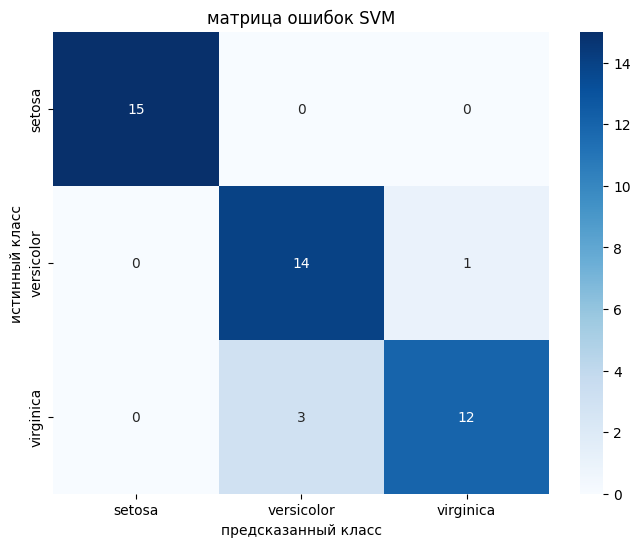

In [35]:
# вычисляем матрицу ошибок
cm = confusion_matrix(y_test, y_pred_best)

# визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('предсказанный класс')
plt.ylabel('истинный класс')
plt.title('матрица ошибок SVM')
plt.show()

In [36]:
print("детальный отчет по классификации:")
print(classification_report(y_test,
                            y_pred_best,
                            target_names=target_names))

# вычисляем дополнительные метрики вручную
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test,
                            y_pred_best,
                            average='weighted')
recall = recall_score(y_test,
                      y_pred_best,
                      average='weighted')
f1 = f1_score(y_test,
              y_pred_best,
              average='weighted')

print(f"\nитоговые метрики:")
print(f"precision: \
{precision:.2%}  # точность (сколько из предсказанных правильные)")
print(f"recall:\
{recall:.2%}    # полнота (сколько из реальных нашли)")
print(f"F1-score:\
{f1:.2%}     # баланс precision и recall")

детальный отчет по классификации:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45


итоговые метрики:
precision: 91.55%  # точность (сколько из предсказанных правильные)
recall:    91.11%    # полнота (сколько из реальных нашли)
F1-score:  91.07%     # баланс precision и recall


In [37]:
# находим индексы ошибок
error_indices = np.where(y_pred_best != y_test)[0]

print(f"количество ошибок: {len(error_indices)}")

if len(error_indices) >= 2:
    print("\nпримеры двух ошибок:")

    for i, idx in enumerate(error_indices[:2]):
        print(f"\nошибка {i+1}:")
        print(f"  истинный класс: {target_names[y_test[idx]]}")
        print(f"  предсказанный:  {target_names[y_pred_best[idx]]}")
        print(f"  вероятности классов: \
{best_svm.decision_function(X_test_scaled[idx:idx+1])}")

количество ошибок: 4

примеры двух ошибок:

ошибка 1:
  истинный класс: virginica
  предсказанный:  versicolor
  вероятности классов: [[-0.26500728  2.26307161  1.03949278]]

ошибка 2:
  истинный класс: virginica
  предсказанный:  versicolor
  вероятности классов: [[-0.26828792  2.26245305  1.09889853]]


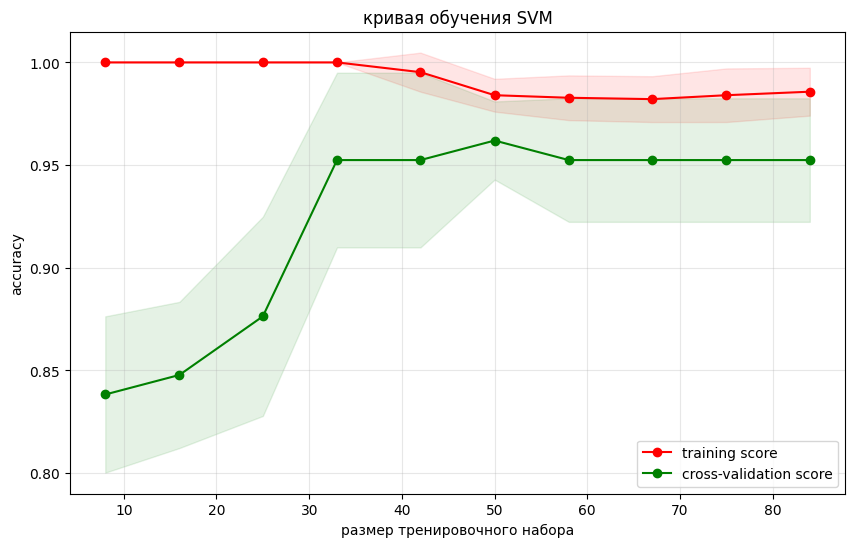

In [38]:
from sklearn.model_selection import learning_curve

# вычисляем learning curve
train_sizes, train_scores, test_scores = learning_curve(
    best_svm, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# средние значения
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# график
plt.figure(figsize=(10, 6))
plt.plot(train_sizes,
         train_mean,
         'o-',
         color='r',
         label='training score')
plt.plot(train_sizes,
         test_mean,
         'o-',
         color='g',
         label='cross-validation score')
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.1, color='r')
plt.fill_between(train_sizes,
                 test_mean - test_std,
                 test_mean + test_std,
                 alpha=0.1,
                 color='g')
plt.xlabel('размер тренировочного набора')
plt.ylabel('accuracy')
plt.title('кривая обучения SVM')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# Выводы:
 Судя по графику, модель переобучается, так как тренировочная шкала выше валидационной. С увеличением данных расстояние между шкалами сокращается, переобучение становится уменьшается. Что можно улучшить: для большей точности можно использовать большее количество данных или поменять ядро на rbf для большей точности accuracy.


# Отчет:
 При вычислении accurac параметров C 0.1, 1 и 10 было получено одинаковое значение 91.11%. Так как значения одинаково высокие, то лучшим может считаться любой из параметров SVM. Ошибки возникают на классах versiocolor и virginica, так как они имеют схожие признаки, т.к на 2д графиках их значения пересекаются друг с другом, а класс setosa находится в отдалении.


# **Здесь я вычисляю accuracy с ядром rbf**

In [39]:
#используем 3 значения С
C_values = [0.1, 1, 10]
accuracies = []

for C in C_values:
    svm_temp = SVC(kernel='rbf', C=C, random_state=42)
    svm_temp.fit(X_train_scaled, y_train)
    acc = svm_temp.score(X_test_scaled, y_test)
    accuracies.append(acc)
    print(f"C={C}: accuracy = {acc:.2%}")

C=0.1: accuracy = 86.67%
C=1: accuracy = 93.33%
C=10: accuracy = 93.33%


In [40]:
# используем найденные лучшие параметры
# используем последний  параметр C
best_svm = SVC(kernel='rbf', C=C, gamma = 'scale', random_state=42)
best_svm.fit(X_train_scaled, y_train)

y_pred_best = best_svm.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"лучшая SVM accuracy: {accuracy_best:.2%}")

лучшая SVM accuracy: 93.33%


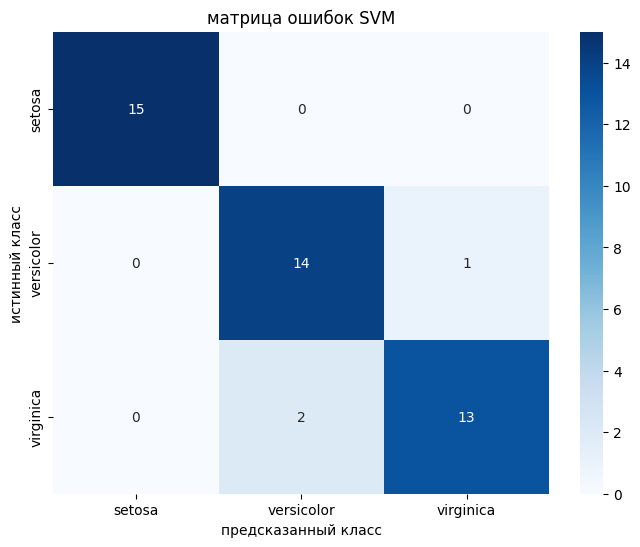

In [41]:
# вычисляем матрицу ошибок
cm = confusion_matrix(y_test, y_pred_best)

# визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('предсказанный класс')
plt.ylabel('истинный класс')
plt.title('матрица ошибок SVM')
plt.show()

In [42]:
print("детальный отчет по классификации:")
print(classification_report
 (y_test, y_pred_best, target_names=target_names))

# вычисляем дополнительные метрики вручную
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred_best, average='weighted')
recall = recall_score(y_test, y_pred_best, average='weighted')
f1 = f1_score(y_test, y_pred_best, average='weighted')

print(f"\nитоговые метрики:")
print(f"precision: {precision:.2%} ")
print(f"recall:    {recall:.2%} "  )
print(f"F1-score:  {f1:.2%} "   )

детальный отчет по классификации:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45


итоговые метрики:
precision: 93.45% 
recall:    93.33% 
F1-score:  93.33% 


In [46]:
# находим индексы ошибок
error_indices = np.where(y_pred_best != y_test)[0]

print(f"количество ошибок: {len(error_indices)}")

if len(error_indices) >= 2:
    print("\nпримеры двух ошибок:")

    for i, idx in enumerate(error_indices[:2]):
        print(f"\nошибка {i+1}:")
        print(f"  истинный класс: {target_names[y_test[idx]]}")
        print(f"  предсказанный:  {target_names[y_pred_best[idx]]}")
        print(f"  вероятности классов: \
{best_svm.decision_function(X_test_scaled[idx:idx+1])}")


количество ошибок: 3

примеры двух ошибок:

ошибка 1:
  истинный класс: virginica
  предсказанный:  versicolor
  вероятности классов: [[-0.23222733  2.20414076  1.13916713]]

ошибка 2:
  истинный класс: virginica
  предсказанный:  versicolor
  вероятности классов: [[-0.22960759  2.18724266  1.16079295]]


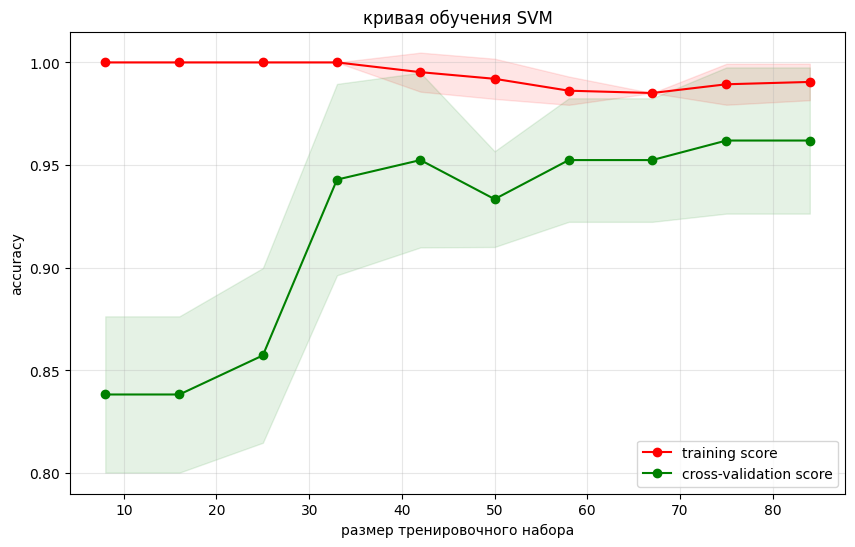

In [44]:
from sklearn.model_selection import learning_curve

# вычисляем learning curve
train_sizes, train_scores, test_scores = learning_curve(
    best_svm, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# средние значения
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# график
plt.figure(figsize=(10, 6))
plt.plot(train_sizes,
         train_mean,
         'o-',
         color='r',
         label='training score')
plt.plot(train_sizes,
         test_mean,
         'o-',
         color='g',
         label='cross-validation score')
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.1,
                 color='r')
plt.fill_between(train_sizes,
                 test_mean - test_std,
                 test_mean + test_std,
                 alpha=0.1,
                 color='g')
plt.xlabel('размер тренировочного набора')
plt.ylabel('accuracy')
plt.title('кривая обучения SVM')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# Выводы:
 Судя по графику, модель переобучается, так как тренировочная шкала выше валидной. С увеличением данных расстояние между шкалами сокращается, переобучение уменьшается так же, как и с linear ядром. Что можно улучшить: для большей точности можно тоже использовать большее количество данных или уменьшить gamma для лучшего переобучения. Интересно, что на значении 50 валидационный график резко меняет шкалу, как и в прошлом графике обучения. С rbf валидационная шкала падает, а с линейным ядром повышается.


# Отчет:
 При вычислении accuracy были найдены следующие значения параметров: C=0.1: accuracy = 86.67%
C=1: accuracy = 93.33%
C=10: accuracy = 93.33%
Лучшими параметрами оказались C=1 и C=10. Ошибки возникают на классах versiocolor и virginica. При вычислении метрик этих классов показатели оказались слегка выше с rbf, чем linear.